In [1]:
import os
import matplotlib as mpl
import numpy as np
import pandas as pd
import scanpy as sc
import celltypist
from celltypist import models


sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, facecolor='white', color_map='viridis')
sc.logging.print_header()

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.26.4 scipy==1.12.0 pandas==1.5.3 scikit-learn==1.4.1.post1 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.11


In [2]:
adata = sc.read_h5ad("Braga_asthma_lung.h5ad")

In [3]:
adata.obs['dataset_id'].value_counts()

Braga_asthma    116638
Name: dataset_id, dtype: int64

In [4]:
adata

AnnData object with n_obs × n_vars = 116638 × 36601
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id'

In [5]:
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.filter_cells(adata, min_counts=10)

filtered out 9133 genes that are detected in less than 10 counts


In [6]:
adata.layers["counts"] = adata.X.copy()

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [8]:
adata.raw = adata  # keep full dimension safe

In [9]:
def adataQc(adata):
    import scrublet as scr
    scrub = scr.Scrublet(adata.X, expected_doublet_rate = 0.076)

    adata.obs['doublet_scores'], adata.obs['predicted_doublets'] = scrub.scrub_doublets(min_counts=2, min_cells=3, min_gene_variability_pctl=85, n_prin_comps=30)



    adata.obs['predicted_doublets'].value_counts()

    
    #scrub.plot_histogram()


    adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
    adata.var['rb'] = adata.var_names.str.startswith(('RPS','RPL'))  # annotate the group of ribosomal proteins as 'rb'
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    sc.pp.calculate_qc_metrics(adata, qc_vars=['rb'], percent_top=None, log1p=False, inplace=True)
    #print('Violin plot to check threshold')
    #sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_rb'], 
         #           jitter=0.4, multi_panel=True)

    #print("Ploting correlations to make sure that high mitochondrial content corresponds with low total counts #(dead cells), and that total counts have strong positive correlation with the number of expressed genes:")

    #sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
    #sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

    #print("High ribosomal protein content, however, strongly anti-correlates with MT, and seems to contain biological signal.")


    #sc.pl.scatter(adata, x='total_counts', y='pct_counts_rb')
    #sc.pl.scatter(adata, x='pct_counts_rb', y='pct_counts_mt')

    #There's also a good correlation between the doublet score and number of expressed genes. 

    #sc.pl.scatter(adata, x='n_genes_by_counts', y='doublet_scores')

    #Let's set QC column in metadata and define it in an informative way. Our metadata table looks as follows.

    #adata.obs.head()

    #The following command allows us to learn what is the data type of each column.

    #adata.obs.dtypes

 #   Let's add a new categorical column that would give us an approximate reason as to why a cell fails QC. Sometimes it would be more than one thing (e.g., low number of expressed genes often happens together with high MT gene content), but for simplicity we would let the order of comparison define the QC category.

    #After we set the values for QC, we can change the data type to 'category', and take a look at the result.

    conditions = [
        (adata.obs['predicted_doublets'] == True),
        (adata.obs['n_genes_by_counts'] < 500),
        (adata.obs['pct_counts_mt'] > 15),
        (adata.obs['pct_counts_mt'] <= 15) & (adata.obs['n_genes_by_counts'] >= 500) &(adata.obs['predicted_doublets'] != True)
    ]

    values = ['Doublet', 'Low_nFeature', 'High_MT', 'Pass']
    adata.obs['QC'] = np.select(conditions, values)
    adata.obs['QC'] = adata.obs['QC'].astype('category')
    adata.obs[['predicted_doublets','n_genes_by_counts','pct_counts_mt','QC']].head(10)

    print(adata.obs['QC'].value_counts())

    #We can see that doublets don't often overlap with cell with low number of detected genes; at the same time, the latter often co-insides with high mitochondrial content. Let's plot metadata only for cells that pass tentative QC: 
    print('Plot of metadata only for cells that pass tentative QC:  \n') 
    
    sc.pl.violin(adata[adata.obs['QC'] == 'Pass'], ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_rb'], 
                 jitter=0.4, multi_panel=True)

    #adata.write_h5ad(path+file)
    #print(file+" saved to "+path)
    #del adata
    #gc.collect()
    
    

    
###### QC plots

def showAdataQc(adata, file):
    print('######################### QC Plot of '+file.split("_modified.curated.h5ad")[0]+' ######################### \n')
    print('######################### Number of cells: '+str(adata.n_obs)+'; '+ 'Number of genes: '+str(adata.n_vars)+' ######################### \n')
    
    print('Violin plot for threshold checking  \n')
    
    sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_rb'], 
                    jitter=0.4, multi_panel=True)
    print('\n')
    print("Ploting correlations to make sure that high mitochondrial content corresponds with low total counts (dead cells), and that total counts have strong positive correlation with the number of expressed genes:  \n")

    sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
    print(' \n')
    sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')
    print('\n')
    print("High ribosomal protein content, strongly anti-correlates with MT  \n")


    sc.pl.scatter(adata, x='total_counts', y='pct_counts_rb')
    print(' \n')
    sc.pl.scatter(adata, x='pct_counts_rb', y='pct_counts_mt')
    print(' \n')
    print('Correlation between doublet score and number of expressed genes  \n') 

    sc.pl.scatter(adata, x='n_genes_by_counts', y='doublet_scores')

    

    print('Plot of metadata only for cells that pass tentative QC:  \n') 

    sc.pl.violin(adata[adata.obs['QC'] == 'Pass'], ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_rb'], 
                 jitter=0.4, multi_panel=True)
    print(' \n')

    del adata
    gc.collect()
    
  
def filter_norma(adata, min_counts=1000, min_genes=500, min_donor=50):
    #sc.pp.filter_cells(adata, min_counts=min_counts)

    sc.pp.filter_cells(adata, min_genes=min_genes)

    adata = adata[adata.obs['QC'] == 'Pass']

    # Remove donors with few than 50 cells
    donor_counts = adata.obs['donor_id'].value_counts()

    donor_counts.sort_values()[:30]

    donor_counts[donor_counts<min_donor].sum()

    adata = adata[adata.obs['donor_id'].isin( donor_counts[donor_counts>=min_donor].index)]
    
    adata.layers["counts"] = adata.X.copy()
# size and log1p normalization
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    adata.raw = adata  # keep full dimension safe
    return adata

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.42
Detected doublet rate = 1.5%
Estimated detectable doublet fraction = 41.7%
Overall doublet rate:
	Expected   = 7.6%
	Estimated  = 3.7%
Elapsed time: 587.9 seconds
Pass            96803
Low_nFeature    18029
Doublet          1806
Name: QC, dtype: int64
Plot of metadata only for cells that pass tentative QC:  



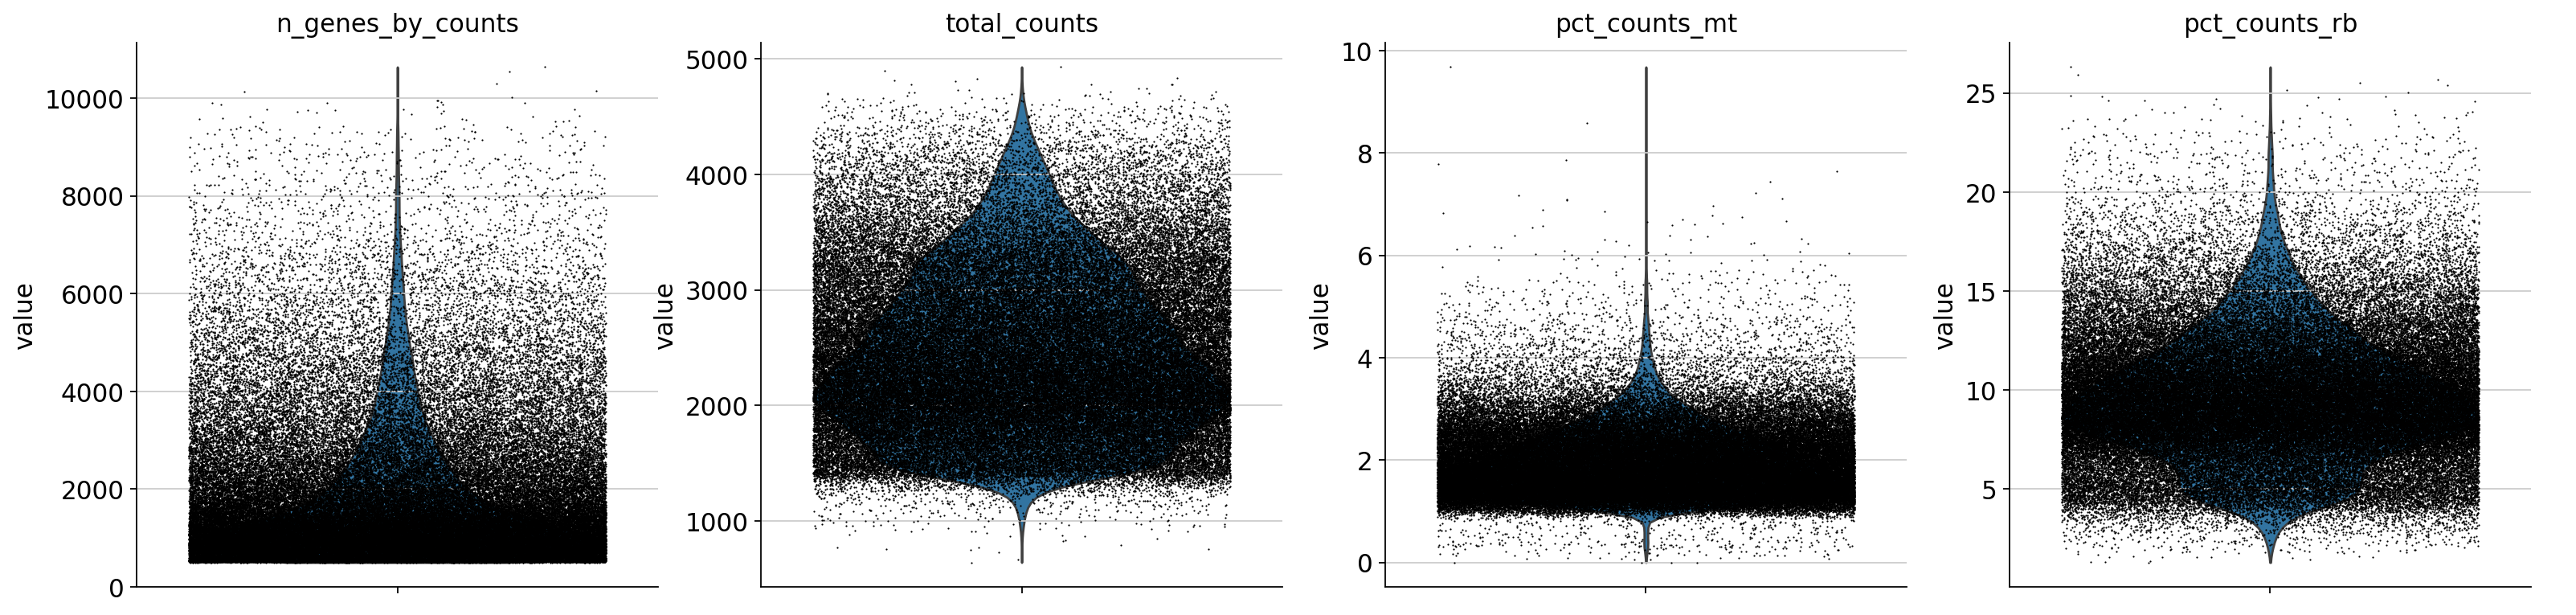

In [10]:
adataQc(adata=adata)

In [11]:
adata = filter_norma(adata=adata, min_genes=500, min_donor=50)

filtered out 18183 cells that have less than 500 genes expressed
normalizing counts per cell
    finished (0:00:00)


In [12]:
adata

AnnData object with n_obs × n_vars = 96803 × 27468
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'
    var: 'n_counts', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts'

In [13]:
adata = adata[adata.obs['QC'] == 'Pass']

In [14]:
adata.X.expm1().sum(axis = 1)

matrix([[10000.   ],
        [ 9999.999],
        [ 9999.999],
        ...,
        [10000.   ],
        [10000.002],
        [ 9999.998]], dtype=float32)

#### Celltypist

In [15]:
# Enabling `force_update = True` will overwrite existing (old) models.
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 44
📂 Storing models in /home/jupyter/.celltypist/data/models
💾 Downloading model [1/44]: Immune_All_Low.pkl
💾 Downloading model [2/44]: Immune_All_High.pkl
💾 Downloading model [3/44]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [4/44]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [5/44]: Adult_Human_Skin.pkl
💾 Downloading model [6/44]: Adult_Mouse_Gut.pkl
💾 Downloading model [7/44]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [8/44]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [9/44]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [10/44]: Autopsy_COVID19_Lung.pkl
💾 Downloading model [11/44]: COVID19_HumanChallenge_Blood.pkl
💾 Downloading model [12/44]: COVID19_Immune_Landscape.pkl
💾 Downloading model [13/44]: Cells_Fetal_Lung.pkl
💾 Downloading model [14/44]: Cells_Intestinal_Tract.pkl
💾 Downloading model [15/44]: Cells_Lung_Airway.p

In [16]:
models.models_description()

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
3,Adult_Human_PancreaticIslet.pkl,cell types from pancreatic islets of healthy a...
4,Adult_Human_Skin.pkl,cell types from human healthy adult skin
5,Adult_Mouse_Gut.pkl,cell types in the adult mouse gut combined fro...
6,Adult_Mouse_OlfactoryBulb.pkl,cell types from the olfactory bulb of adult mice
7,Adult_Pig_Hippocampus.pkl,cell types from the adult pig hippocampus
8,Adult_RhesusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult rhesu...
9,Autopsy_COVID19_Lung.pkl,cell types from the lungs of 16 SARS-CoV-2 inf...


In [17]:
# Indeed, the `model` argument defaults to `Immune_All_Low.pkl`.
model = models.Model.load(model = 'Human_Lung_Atlas.pkl')

In [18]:
len(model.cell_types)

61

In [19]:
import gc
del model
gc.collect()


12503

In [20]:
predictions = celltypist.annotate(adata, model = 'Human_Lung_Atlas.pkl', majority_voting = True)

🔬 Input data has 96803 cells and 27468 genes
🔗 Matching reference genes in the model
🧬 4873 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering


filtered out 5 genes that are detected in less than 5 cells
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:05)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:11)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:22)


⛓️ Over-clustering input data with resolution set to 20


running Leiden clustering
    finished: found 309 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:34)


🗳️ Majority voting the predictions
✅ Majority voting done!


In [21]:
predictions_2 = celltypist.annotate(adata, model = 'Human_Lung_Atlas.pkl', majority_voting = True)

🔬 Input data has 96803 cells and 27468 genes
🔗 Matching reference genes in the model
🧬 4873 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20


running Leiden clustering
    finished: found 309 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:35)


🗳️ Majority voting the predictions
✅ Majority voting done!


In [22]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
AAACCTGAGAGCAATT-0,Multiciliated (non-nasal),122,Multiciliated (non-nasal)
AAACCTGCACGGATAG-0,Multiciliated (non-nasal),34,Multiciliated (non-nasal)
AAACCTGCACGGTAAG-0,Multiciliated (non-nasal),12,Multiciliated (non-nasal)
AAACCTGCATCACGAT-0,Multiciliated (non-nasal),148,Multiciliated (non-nasal)
AAACCTGGTAAACGCG-0,Multiciliated (non-nasal),161,Multiciliated (non-nasal)
...,...,...,...
TTTGTCACAGGACCCT-1-1-1-1-1-1-1-1-1-1-1,CD8 T cells,1,CD8 T cells
TTTGTCACATTCGACA-1-1-1-1-1-1-1-1-1-1-1,Multiciliated (non-nasal),42,Multiciliated (non-nasal)
TTTGTCAGTGGTTTCA-1-1-1-1-1-1-1-1-1-1-1,Suprabasal,156,Suprabasal
TTTGTCAGTGTAATGA-1-1-1-1-1-1-1-1-1-1-1,CD4 T cells,132,CD4 T cells


In [23]:
# Get an `AnnData` with predicted labels embedded into the cell metadata columns.
adata_celltypist = predictions.to_adata()

In [24]:
adata_celltypist

AnnData object with n_obs × n_vars = 96803 × 27468
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    var: 'n_counts', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p', 'neighbors', 'leiden'
    obsm: 'X_pca'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [25]:
predicted_main_cells = predictions_2.predicted_labels

In [26]:
predicted_main_cells = predicted_main_cells[['majority_voting']]

In [27]:
predicted_main_cells = predicted_main_cells.rename(columns={'majority_voting':'main_predicted_cell_groups'})

In [28]:
predicted_main_cells

,main_predicted_cell_groups
AAACCTGAGAGCAATT-0,Multiciliated (non-nasal)
AAACCTGCACGGATAG-0,Multiciliated (non-nasal)
AAACCTGCACGGTAAG-0,Multiciliated (non-nasal)
AAACCTGCATCACGAT-0,Multiciliated (non-nasal)
AAACCTGGTAAACGCG-0,Multiciliated (non-nasal)
...,...
TTTGTCACAGGACCCT-1-1-1-1-1-1-1-1-1-1-1,CD8 T cells
TTTGTCACATTCGACA-1-1-1-1-1-1-1-1-1-1-1,Multiciliated (non-nasal)
TTTGTCAGTGGTTTCA-1-1-1-1-1-1-1-1-1-1-1,Suprabasal
TTTGTCAGTGTAATGA-1-1-1-1-1-1-1-1-1-1-1,CD4 T cells


In [29]:
adata_celltypist.obs['main_predicted_cell_groups'] = predicted_main_cells

In [30]:
adata_celltypist.obs['main_predicted_cell_groups'].value_counts()

Multiciliated (non-nasal)    33032
Suprabasal                   22014
Basal resting                12363
CD8 T cells                   7264
CD4 T cells                   4595
Club (non-nasal)              4052
EC venous systemic            3208
DC2                           1700
Classical monocytes           1671
Peribronchial fibroblasts     1182
B cells                        802
Mast cells                     793
Plasma cells                   558
Goblet (bronchial)             508
Goblet (nasal)                 465
Smooth muscle                  415
NK cells                       371
SMG duct                       313
Ionocyte                       279
SMG serous (bronchial)         270
Non-classical monocytes        240
EC arterial                    224
SMG mucous                     184
Alveolar macrophages           133
Plasmacytoid DCs               126
Lymphatic EC mature             41
Name: main_predicted_cell_groups, dtype: int64

In [31]:
adata_celltypist.write_h5ad('Braga_asthma_lung_celltypist.h5ad')

In [37]:
adata.obs

,dataset_id,donor_id,tissue,cell_source,disease,disease_status,age,sex,developmental_stage,sample_id,...,pct_counts_mt,total_counts_rb,pct_counts_rb,QC,n_genes,predicted_labels,over_clustering,majority_voting,conf_score,main_predicted_cell_groups
AAACCTGAGAGCAATT-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAACCTGAGAGCAATT,...,1.689117,153.072296,4.659235,Pass,2306,Multiciliated (non-nasal),122,Multiciliated (non-nasal),0.999972,Multiciliated (non-nasal)
AAACCTGCACGGATAG-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAACCTGCACGGATAG,...,2.295127,177.677704,8.864533,Pass,827,Multiciliated (non-nasal),34,Multiciliated (non-nasal),0.999692,Multiciliated (non-nasal)
AAACCTGCACGGTAAG-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAACCTGCACGGTAAG,...,1.898988,182.302307,6.274046,Pass,1966,Multiciliated (non-nasal),12,Multiciliated (non-nasal),0.998608,Multiciliated (non-nasal)
AAACCTGCATCACGAT-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAACCTGCATCACGAT,...,2.239695,157.092072,9.620240,Pass,599,Multiciliated (non-nasal),148,Multiciliated (non-nasal),0.999549,Multiciliated (non-nasal)
AAACCTGGTAAACGCG-0,Braga_asthma,CTTV027_RNAseq7018936,lung,NaN,Asthma,NaN,NaN,NaN,NaN,AAACCTGGTAAACGCG,...,1.865778,194.211212,8.615896,Pass,1029,Multiciliated (non-nasal),161,Multiciliated (non-nasal),0.998344,Multiciliated (non-nasal)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACAGGACCCT-1-1-1-1-1-1-1-1-1-1-1,Braga_asthma,CTTV027_RNAseq6949177,lung,NaN,Asthma,NaN,NaN,NaN,NaN,TTTGTCACAGGACCCT,...,1.938684,189.241608,10.911060,Pass,772,CD8 T cells,1,CD8 T cells,0.696028,CD8 T cells
TTTGTCACATTCGACA-1-1-1-1-1-1-1-1-1-1-1,Braga_asthma,CTTV027_RNAseq6949177,lung,NaN,Asthma,NaN,NaN,NaN,NaN,TTTGTCACATTCGACA,...,1.987400,124.804405,4.473729,Pass,1840,Multiciliated (non-nasal),42,Multiciliated (non-nasal),0.999672,Multiciliated (non-nasal)
TTTGTCAGTGGTTTCA-1-1-1-1-1-1-1-1-1-1-1,Braga_asthma,CTTV027_RNAseq6949177,lung,NaN,Asthma,NaN,NaN,NaN,NaN,TTTGTCAGTGGTTTCA,...,1.070788,267.703400,7.076146,Pass,8532,Suprabasal,156,Suprabasal,0.071885,Suprabasal
TTTGTCAGTGTAATGA-1-1-1-1-1-1-1-1-1-1-1,Braga_asthma,CTTV027_RNAseq6949177,lung,NaN,Asthma,NaN,NaN,NaN,NaN,TTTGTCAGTGTAATGA,...,1.859735,305.065186,15.425751,Pass,1150,CD4 T cells,132,CD4 T cells,0.999931,CD4 T cells


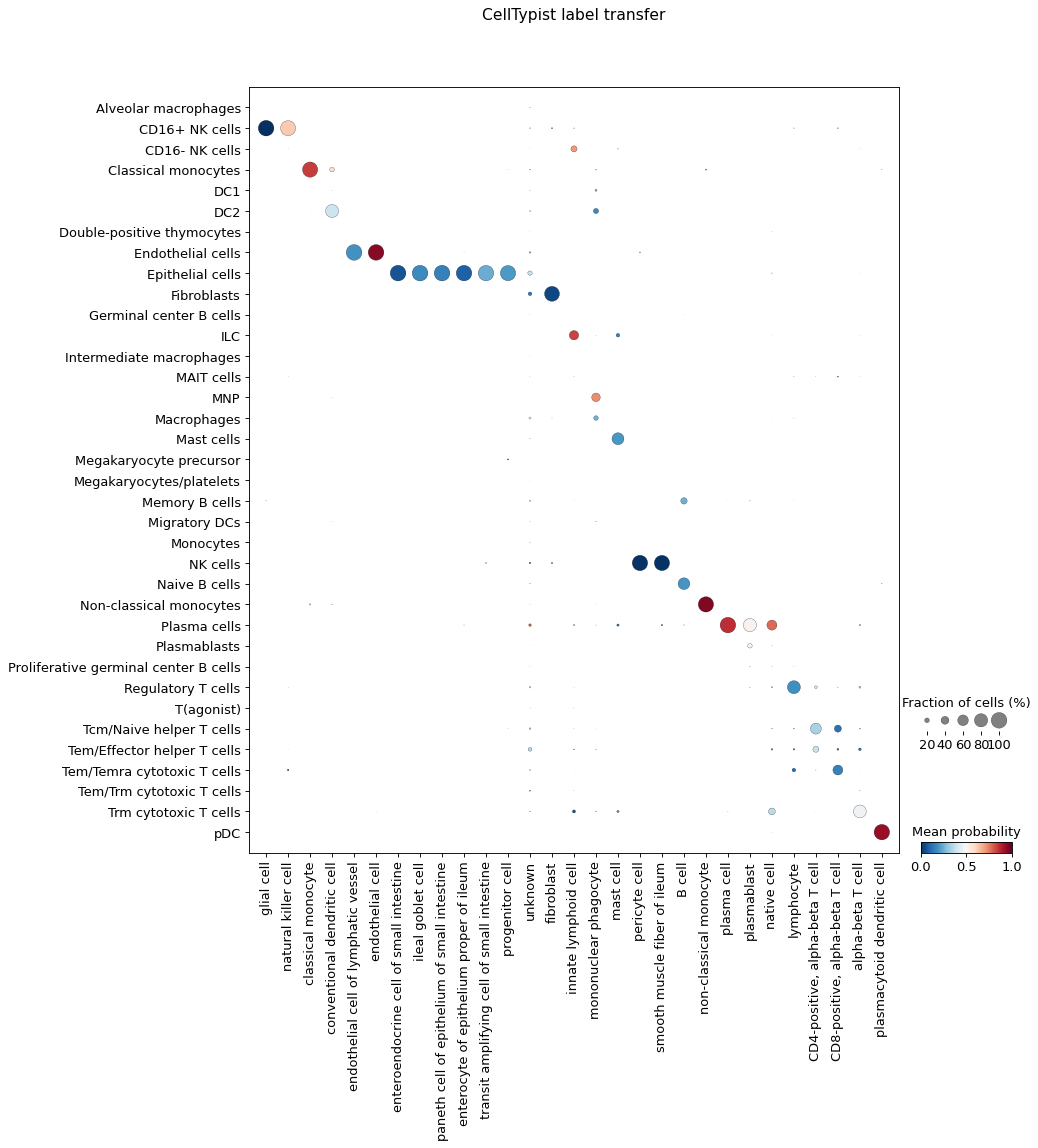

In [21]:
celltypist.dotplot(predictions, use_as_reference = 'cell_type', use_as_prediction = 'majority_voting')